In [ ]:
!kaggle datasets download uciml/default-of-credit-card-clients-dataset

Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
License(s): CC0-1.0
100% 0.98M/0.98M [00:00<00:00, 112MB/s]



In [ ]:
!unzip default-of-credit-card-clients-dataset.zip

Archive:  default-of-credit-card-clients-dataset.zip
  inflating: UCI_Credit_Card.csv     


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
df = pd.read_csv('UCI_Credit_Card.csv')

In [ ]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
df.shape

(30000, 25)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [ ]:
df.drop(columns='ID',inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

In [ ]:
df['default.payment.next.month'].value_counts()

,count
default.payment.next.month,
0,23364
1,6636


In [ ]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader,TensorDataset

X = df.drop('default.payment.next.month',axis=1)
y = df['default.payment.next.month']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train.values).view(-1,1)
y_valid = torch.FloatTensor(y_valid.values).view(-1,1)
y_test = torch.FloatTensor(y_test.values).view(-1,1)

train_dataset = TensorDataset(X_train,y_train)
valid_dataset = TensorDataset(X_valid,y_valid)
test_dataset = TensorDataset(X_test,y_test)

train_loader =  DataLoader(train_dataset,batch_size=32,shuffle=True)
valid_loader =  DataLoader(valid_dataset,batch_size=32,shuffle=True)
test_loader =  DataLoader(test_dataset,batch_size=32,shuffle=True)

In [ ]:
%pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 8.5 MB/s eta 0:00:00


In [ ]:
import torch.nn as nn
import torchmetrics

In [ ]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
    history = {
        'loss': [],
        'train_metric': [],
        'valid_metric': [],
    }

    for epoch in range(n_epochs):
        # Training
        total_loss = 0
        metric.reset()

        for X_batch, y_batch in train_loader:
            model.train()

            y_pred = model(X_batch)
            y_batch = y_batch.squeeze().long()
            loss = criterion(y_pred, y_batch)

            total_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            pred = torch.argmax(y_pred, dim=1)
            metric.update(pred, y_batch)

        avg_loss = total_loss / len(train_loader)
        history['loss'].append(avg_loss)

        avg_metric_train = metric.compute().item()
        history['train_metric'].append(avg_metric_train)

        # Evaluation
        model.eval()
        metric.reset()

        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                y_pred = model(X_batch)
                y_batch = y_batch.squeeze().long()
                pred = torch.argmax(y_pred, dim=1)
                metric.update(pred, y_batch)

        avg_metric_valid = metric.compute().item()
        history['valid_metric'].append(avg_metric_valid)

        print(
            f'Epoch: {epoch+1}/{n_epochs}, '
            f'Loss: {round(avg_loss,3)}, '
            f'Train Metric: {round(avg_metric_train,3)}, '
            f'Valid Metric: {round(avg_metric_valid,3)}'
        )

    return history


def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Epoch: 1/20, Loss: 0.52, Train Metric: 0.78, Valid Metric: 0.785
Epoch: 2/20, Loss: 0.478, Train Metric: 0.798, Valid Metric: 0.801
Epoch: 3/20, Loss: 0.464, Train Metric: 0.806, Valid Metric: 0.805
Epoch: 4/20, Loss: 0.455, Train Metric: 0.81, Valid Metric: 0.809
Epoch: 5/20, Loss: 0.449, Train Metric: 0.812, Valid Metric: 0.808
Epoch: 6/20, Loss: 0.446, Train Metric: 0.814, Valid Metric: 0.81
Epoch: 7/20, Loss: 0.443, Train Metric: 0.816, Valid Metric: 0.814
Epoch: 8/20, Loss: 0.441, Train Metric: 0.817, Valid Metric: 0.813
Epoch: 9/20, Loss: 0.439, Train Metric: 0.818, Valid Metric: 0.813
Epoch: 10/20, Loss: 0.438, Train Metric: 0.82, Valid Metric: 0.812
Epoch: 11/20, Loss: 0.436, Train Metric: 0.822, Valid Metric: 0.814
Epoch: 12/20, Loss: 0.435, Train Metric: 0.822, Valid Metric: 0.814
Epoch: 13/20, Loss: 0.434, Train Metric: 0.822, Valid Metric: 0.814
Epoch: 14/20, Loss: 0.433, Train Metric: 0.822, Valid Metric: 0.813
Epoch: 15/20, Loss: 0.433, Train Metric: 0.822, Valid Metric: 

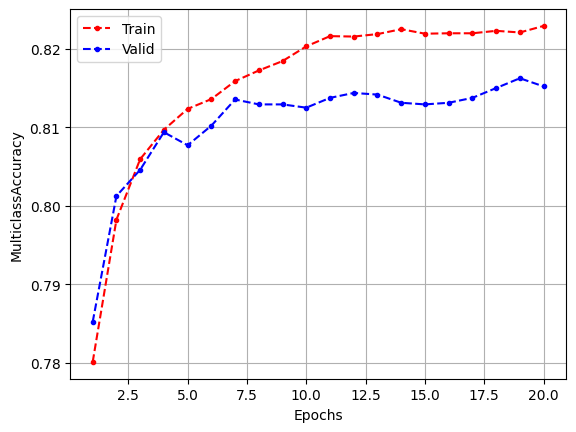

In [ ]:
learning_rate = 0.01
n_epochs=20

model = nn.Sequential(
	nn.Linear(in_features=23, out_features=30),
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50),
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=2)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.Accuracy(task='multiclass',num_classes=2)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs, metric)

In [ ]:
model.eval()
metric.reset()

with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        y_pred_logits = model(X_batch)

        y_pred = y_pred_logits.argmax(dim=1)

        y_batch = y_batch.squeeze().long()

        metric.update(y_pred, y_batch)

avg_metric_test = metric.compute().item()

print(f'Test Metric: {round(avg_metric_test, 3)}')

Test Metric: 0.82
